<a href="https://colab.research.google.com/github/nzoopxw/deep-learning-lab-sem5/blob/main/dl_lab_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q "scikeras>=0.13.0"
import tensorflow as tf, keras, scikeras, os
print("TF:", tf.__version__, "| Keras:", keras.__version__, "| SciKeras:", scikeras.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
os.makedirs("plots", exist_ok=True)

TF: 2.20.0 | Keras: 3.13.2 | SciKeras: 0.13.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!apt-get install -qq -y msttcorefonts > /dev/null 2>&1
!rm -rf ~/.cache/matplotlib
import os; os.makedirs("/root/.cache/matplotlib", exist_ok=True)
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
import tensorflow as tf
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.utils import to_categorical
from keras.optimizers import Adam, SGD, RMSprop
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
})

np.random.seed(42); tf.random.set_seed(42)

CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [4]:
# task 1

# loading Fashion-MNIST dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = fashion_mnist.load_data()

# printing dataset dimensions
print("Training images :", x_train_raw.shape)
print("Training labels :", y_train_raw.shape)
print("Testing images  :", x_test_raw.shape)
print("Testing labels  :", y_test_raw.shape)
print("Pixel range     :", x_train_raw.min(), "to", x_train_raw.max())
print("Number of classes:", len(np.unique(y_train_raw)))

Training images : (60000, 28, 28)
Training labels : (60000,)
Testing images  : (10000, 28, 28)
Testing labels  : (10000,)
Pixel range     : 0 to 255
Number of classes: 10


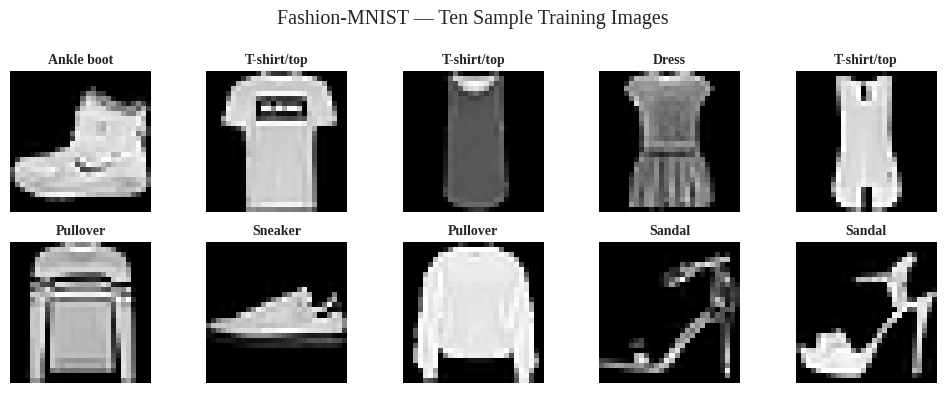

In [5]:
# task 1

# displaying 10 sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_raw[i], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train_raw[i]], fontsize=10)
    ax.axis('off')
plt.suptitle("Fashion-MNIST — Ten Sample Training Images")
plt.tight_layout()
plt.savefig("plots/01_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

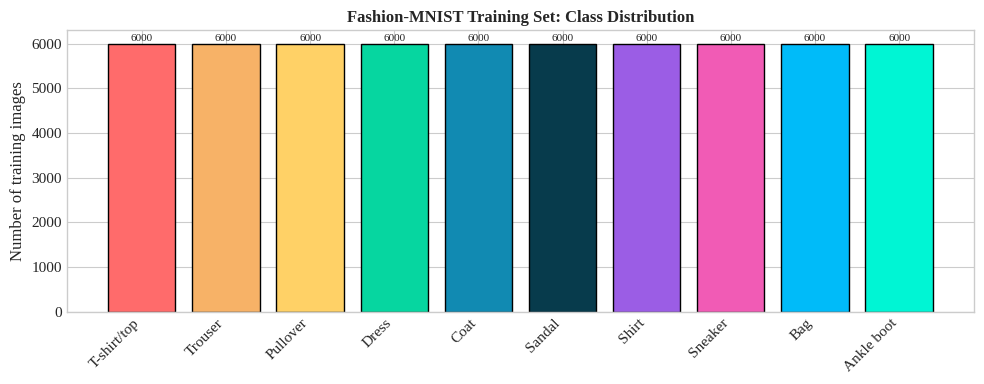

Counts per class: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


In [6]:
# task 1

counts = np.bincount(y_train_raw)
plt.figure(figsize=(10, 4))
colours = [
    "#FF6B6B",
    "#F7B267",
    "#FFD166",
    "#06D6A0",
    "#118AB2",
    "#073B4C",
    "#9B5DE5",
    "#F15BB5",
    "#00BBF9",
    "#00F5D4"
]

plt.bar(CLASS_NAMES, counts,
        color=colours,
        edgecolor="black")
plt.ylabel("Number of training images")
plt.xticks(rotation=45, ha='right')
plt.title("Fashion-MNIST Training Set: Class Distribution")
for i, c in enumerate(counts):
    plt.text(i, c + 60, str(c), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig("plots/02_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Counts per class:", counts)

In [7]:
# task 2

print("Before preprocessing: ")
print("  x_train:", x_train_raw.shape, "| dtype:", x_train_raw.dtype)
print("  x_test :", x_test_raw.shape,  "| dtype:", x_test_raw.dtype)
print("  y_train:", y_train_raw.shape, "| dtype:", y_train_raw.dtype)
print("  Pixel range:", x_train_raw.min(), "to", x_train_raw.max())

# Flattening 28x28 -> 784
x_train_full = x_train_raw.reshape(-1, 784).astype('float32')/255.0
x_test       = x_test_raw.reshape(-1, 784).astype('float32')/255.0

# One-hot encoding labels [integer to vectors of length 10]
y_train_full = to_categorical(y_train_raw, 10)
y_test       = to_categorical(y_test_raw, 10)

print("\nAfter preprocessing: ")
print("  x_train:", x_train_full.shape, "| dtype:", x_train_full.dtype)
print("  x_test :", x_test.shape,       "| dtype:", x_test.dtype)
print("  y_train:", y_train_full.shape, "(one-hot)")
print("  Pixel range:", x_train_full.min(), "to", x_train_full.max())

Before preprocessing: 
  x_train: (60000, 28, 28) | dtype: uint8
  x_test : (10000, 28, 28) | dtype: uint8
  y_train: (60000,) | dtype: uint8
  Pixel range: 0 to 255

After preprocessing: 
  x_train: (60000, 784) | dtype: float32
  x_test : (10000, 784) | dtype: float32
  y_train: (60000, 10) (one-hot)
  Pixel range: 0.0 to 1.0


In [8]:
# task 3

baseline = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(10,  activation='softmax')
])

baseline.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# task 4

# Validation split for the training-curve plots
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_full, y_train_full, test_size=10000, random_state=42)
print("Train split:", x_tr.shape, "| Validation split:", x_val.shape, "\n")

# Adam, Categorical Cross Entropy, Accuracy
baseline.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# Training for 20 epochs, batch size 32
t0 = time.perf_counter()
history = baseline.fit(x_tr, y_tr,
                       validation_data=(x_val, y_val),
                       epochs=20, batch_size=32, verbose=2)
baseline_time = time.perf_counter() - t0
print(f"\nBaseline training time: {baseline_time:.1f} s")

Train split: (50000, 784) | Validation split: (10000, 784) 

Epoch 1/20
1563/1563 - 14s - 9ms/step - accuracy: 0.8177 - loss: 0.5108 - val_accuracy: 0.8506 - val_loss: 0.3988
Epoch 2/20
1563/1563 - 4s - 3ms/step - accuracy: 0.8634 - loss: 0.3750 - val_accuracy: 0.8609 - val_loss: 0.3743
Epoch 3/20
1563/1563 - 9s - 6ms/step - accuracy: 0.8775 - loss: 0.3350 - val_accuracy: 0.8684 - val_loss: 0.3601
Epoch 4/20
1563/1563 - 9s - 6ms/step - accuracy: 0.8854 - loss: 0.3087 - val_accuracy: 0.8720 - val_loss: 0.3496
Epoch 5/20
1563/1563 - 7s - 4ms/step - accuracy: 0.8923 - loss: 0.2899 - val_accuracy: 0.8692 - val_loss: 0.3627
Epoch 6/20
1563/1563 - 5s - 3ms/step - accuracy: 0.8987 - loss: 0.2725 - val_accuracy: 0.8788 - val_loss: 0.3368
Epoch 7/20
1563/1563 - 4s - 3ms/step - accuracy: 0.9030 - loss: 0.2585 - val_accuracy: 0.8790 - val_loss: 0.3438
Epoch 8/20
1563/1563 - 4s - 3ms/step - accuracy: 0.9080 - loss: 0.2467 - val_accuracy: 0.8763 - val_loss: 0.3547
Epoch 9/20
1563/1563 - 5s - 3ms/st

In [10]:
# task 5

def evaluate(model, name):
    probs = model.predict(x_test, verbose=0)
    pred  = np.argmax(probs, axis=1)          # one-hot probs -> integer labels
    metrics = dict(
        accuracy  = accuracy_score(y_test_raw, pred),
        precision = precision_score(y_test_raw, pred, average='macro'),
        recall    = recall_score(y_test_raw, pred, average='macro'),
        f1        = f1_score(y_test_raw, pred, average='macro'))
    print(f"===== {name} =====")
    for k, v in metrics.items():
        print(f"  {k.capitalize():10s}: {v:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_raw, pred,
                                target_names=CLASS_NAMES, digits=4))
    return metrics, pred

baseline_metrics, baseline_pred = evaluate(baseline, "BASELINE MODEL")

===== BASELINE MODEL =====
  Accuracy  : 0.8709
  Precision : 0.8751
  Recall    : 0.8709
  F1        : 0.8719

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top     0.8692    0.7640    0.8132      1000
     Trouser     0.9858    0.9720    0.9789      1000
    Pullover     0.8136    0.7420    0.7762      1000
       Dress     0.8630    0.8570    0.8600      1000
        Coat     0.7660    0.7790    0.7724      1000
      Sandal     0.9457    0.9750    0.9601      1000
       Shirt     0.6348    0.7580    0.6910      1000
     Sneaker     0.9513    0.9380    0.9446      1000
         Bag     0.9615    0.9730    0.9672      1000
  Ankle boot     0.9606    0.9510    0.9558      1000

    accuracy                         0.8709     10000
   macro avg     0.8751    0.8709    0.8719     10000
weighted avg     0.8751    0.8709    0.8719     10000



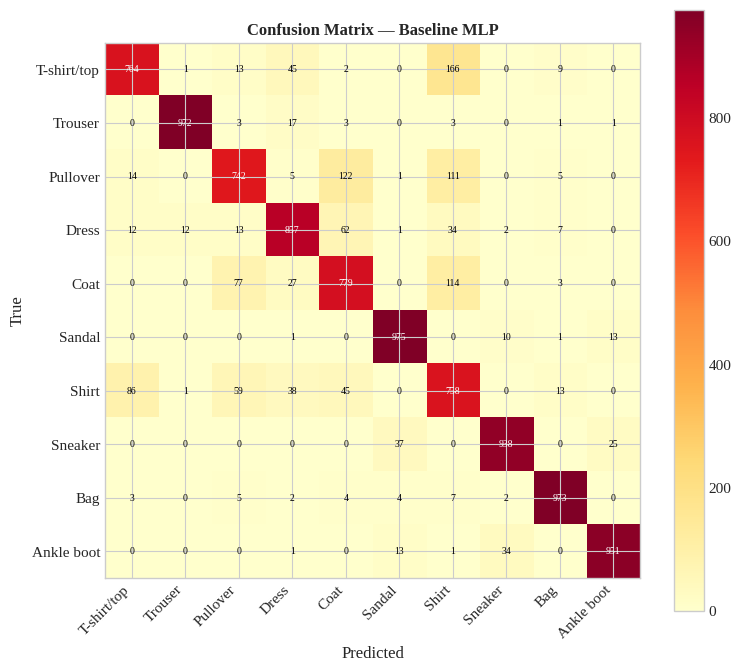

In [11]:
# task 5 - confusion matrix

def plot_cm(pred, title, fname):
    cm = confusion_matrix(y_test_raw, pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap='YlOrRd')
    fig.colorbar(im)
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7,
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.tight_layout()
    plt.savefig(f"plots/{fname}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return cm

cm_base = plot_cm(baseline_pred, "Confusion Matrix — Baseline MLP", "07_confusion_baseline")

In [12]:
# 7

def build_model(n_layers=2, n_neurons=128, activation='relu',
                dropout=0.0, optimizer='adam', learning_rate=0.001):
    model = Sequential([Input(shape=(784,))])
    for _ in range(n_layers):
        model.add(Dense(n_neurons, activation=activation))
        if dropout > 0:
            model.add(Dropout(dropout))
    model.add(Dense(10, activation='softmax'))
    opt = {'adam': Adam, 'sgd': SGD, 'rmsprop': RMSprop}[optimizer](learning_rate=learning_rate)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

clf = KerasClassifier(model=build_model, verbose=0,
                      n_layers=2, n_neurons=128, activation='relu',
                      dropout=0.0, optimizer='adam', learning_rate=0.001,
                      loss='categorical_crossentropy')

In [15]:
param_dist = {
    'n_layers':      [1, 2, 3],
    'n_neurons':     [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'batch_size':    [16, 32, 64, 128],
    'epochs':        [10],
    'optimizer':     ['sgd', 'adam', 'rmsprop'],
    'activation':    ['relu', 'tanh', 'sigmoid'],
    'dropout':       [0.0, 0.2, 0.5],
}

# Subsample training data
SUB = 15000
idx = np.random.choice(len(x_train_full), SUB, replace=False)
x_sub, y_sub = x_train_full[idx], y_train_full[idx]

search = RandomizedSearchCV(clf, param_dist, n_iter=20, cv=5, n_jobs=1,
                            verbose=2, random_state=42, scoring='accuracy')
t0 = time.perf_counter()
search.fit(x_sub, y_sub)
search_time = (time.perf_counter() - t0) / 60
print(f"\nSearch wall time: {search_time:.1f} min")

pd.DataFrame(search.cv_results_).to_csv("cv_results.csv", index=False)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END activation=sigmoid, batch_size=32, dropout=0.5, epochs=10, learning_rate=0.01, n_layers=1, n_neurons=128, optimizer=sgd; total time=  12.9s
[CV] END activation=sigmoid, batch_size=32, dropout=0.5, epochs=10, learning_rate=0.01, n_layers=1, n_neurons=128, optimizer=sgd; total time=  12.2s
[CV] END activation=sigmoid, batch_size=32, dropout=0.5, epochs=10, learning_rate=0.01, n_layers=1, n_neurons=128, optimizer=sgd; total time=  12.0s
[CV] END activation=sigmoid, batch_size=32, dropout=0.5, epochs=10, learning_rate=0.01, n_layers=1, n_neurons=128, optimizer=sgd; total time=  16.8s
[CV] END activation=sigmoid, batch_size=32, dropout=0.5, epochs=10, learning_rate=0.01, n_layers=1, n_neurons=128, optimizer=sgd; total time=  20.0s
[CV] END activation=sigmoid, batch_size=64, dropout=0.5, epochs=10, learning_rate=0.01, n_layers=2, n_neurons=64, optimizer=sgd; total time=  10.4s
[CV] END activation=sigmoid, batch_size=64, d

In [16]:
print("Best 5-fold CV accuracy:", round(search.best_score_, 4))
print("\nBest hyperparameters:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:14s}: {v}")

Best 5-fold CV accuracy: 0.8556

Best hyperparameters:
  activation    : relu
  batch_size    : 64
  dropout       : 0.2
  epochs        : 10
  learning_rate : 0.001
  n_layers      : 3
  n_neurons     : 128
  optimizer     : rmsprop


In [17]:
bp = search.best_params_
opt_model = build_model(n_layers=bp['n_layers'], n_neurons=bp['n_neurons'],
                        activation=bp['activation'], dropout=bp['dropout'],
                        optimizer=bp['optimizer'], learning_rate=bp['learning_rate'])
opt_model.summary()

FINAL_EPOCHS = 20
t0 = time.perf_counter()
opt_history = opt_model.fit(x_tr, y_tr, validation_data=(x_val, y_val),
                            epochs=FINAL_EPOCHS, batch_size=bp['batch_size'], verbose=2)
optimized_time = time.perf_counter() - t0
print(f"\nOptimized training time: {optimized_time:.1f} s")

Model: "sequential_102"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_307 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_183 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_308 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_184 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_309 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_185 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_310 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
782/782 - 7s - 10ms/step - accuracy: 0.7738 - loss: 0.6295 - val_accuracy: 0.7826 - val_loss: 0.5674
Epoch 2/20
782/782 - 2s - 3ms/step - accuracy: 0.8382 - loss: 0.4515 - val_accuracy: 0.8309 - val_loss: 0.4706
Epoch 3/20
782/782 - 3s - 4ms/step - accuracy: 0.8534 - loss: 0.4125 - val_accuracy: 0.8496 - val_loss: 0.4262
Epoch 4/20
782/782 - 3s - 3ms/step - accuracy: 0.8596 - loss: 0.3907 - val_accuracy: 0.8546 - val_loss: 0.3921
Epoch 5/20
782/782 - 2s - 3ms/step - accuracy: 0.8635 - loss: 0.3790 - val_accuracy: 0.8606 - val_loss: 0.3722
Epoch 6/20
782/782 - 2s - 3ms/step - accuracy: 0.8699 - loss: 0.3659 - val_accuracy: 0.8627 - val_loss: 0.3770
Epoch 7/20
782/782 - 2s - 3ms/step - accuracy: 0.8720 - loss: 0.3605 - val_accuracy: 0.8596 - val_loss: 0.3931
Epoch 8/20
782/782 - 2s - 3ms/step - accuracy: 0.8748 - loss: 0.3585 - val_accuracy: 0.8584 - val_loss: 0.3972
Epoch 9/20
782/782 - 3s - 4ms/step - accuracy: 0.8747 - loss: 0.3528 - val_accuracy: 0.8732 - val_loss: 0.3739


===== OPTIMIZED MODEL =====
  Accuracy  : 0.8701
  Precision : 0.8701
  Recall    : 0.8701
  F1        : 0.8686

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top     0.8630    0.7560    0.8060      1000
     Trouser     0.9917    0.9610    0.9761      1000
    Pullover     0.7660    0.8150    0.7897      1000
       Dress     0.7907    0.9370    0.8577      1000
        Coat     0.8051    0.7520    0.7777      1000
      Sandal     0.9724    0.9520    0.9621      1000
       Shirt     0.7060    0.6340    0.6681      1000
     Sneaker     0.9336    0.9560    0.9447      1000
         Bag     0.9211    0.9800    0.9496      1000
  Ankle boot     0.9513    0.9580    0.9547      1000

    accuracy                         0.8701     10000
   macro avg     0.8701    0.8701    0.8686     10000
weighted avg     0.8701    0.8701    0.8686     10000



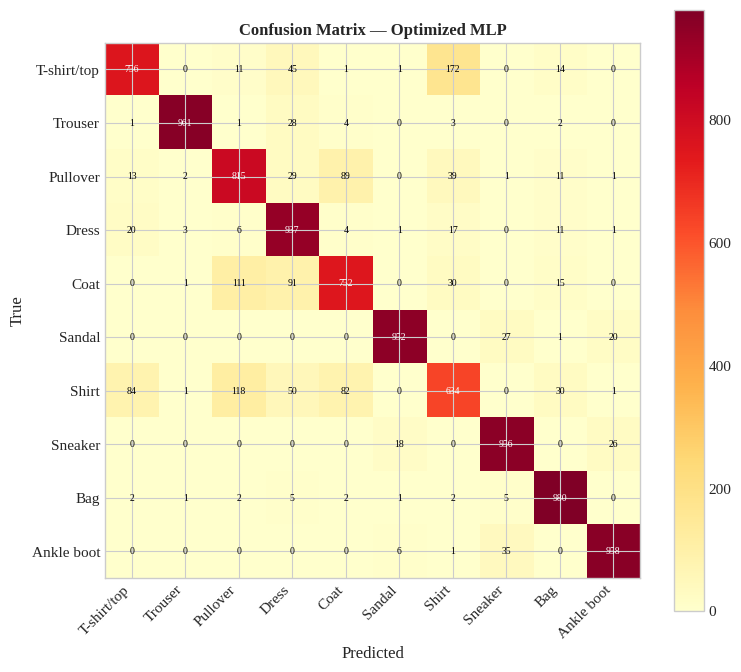


--- COPY INTO REPORT ---
Metric              Baseline   Optimized
Accuracy              0.8709      0.8701
Precision             0.8751      0.8701
Recall                0.8709      0.8701
F1-score              0.8719      0.8686
Training Time         114.9s       54.5s

Best params: {'optimizer': 'rmsprop', 'n_neurons': 128, 'n_layers': 3, 'learning_rate': 0.001, 'epochs': 10, 'dropout': 0.2, 'batch_size': 64, 'activation': 'relu'}
Best CV accuracy: 0.8556


In [18]:
optimized_metrics, optimized_pred = evaluate(opt_model, "OPTIMIZED MODEL")
cm_opt = plot_cm(optimized_pred, "Confusion Matrix — Optimized MLP", "07b_confusion_optimized")

labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
b = [baseline_metrics[k]  for k in ['accuracy','precision','recall','f1']]
o = [optimized_metrics[k] for k in ['accuracy','precision','recall','f1']]

print("\n--- COPY INTO REPORT ---")
print(f"{'Metric':<16}{'Baseline':>12}{'Optimized':>12}")
for lab, bb, oo in zip(labels, b, o):
    print(f"{lab:<16}{bb:>12.4f}{oo:>12.4f}")
print(f"{'Training Time':<16}{baseline_time:>11.1f}s{optimized_time:>11.1f}s")
print("\nBest params:", bp)
print("Best CV accuracy:", round(search.best_score_, 4))